# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs) 
3. sapphire.run(parameters) 

Soon there will be a way to run from the command line "python -m sapphire config.json" 
(useful if you want to run many parameter variations simultaneously on different nodes) 

In [26]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck15

import sapphire 

In [2]:
# set up a general parameters dict 

# try running new thermal_general model on same 656 TNG trees 
parameters = {'output_path':'/Users/viraj/sapphire/localdev/', # path where any output files should be saved (irrelevant if return_or_write=='return' below)
              
              ### merger tree related parameters (you only need to vary tree_path) 
              
              'tree_type':'tng_sapphire', # type of merger trees / MAHs -- this determines what read_trees module gets loaded
              'tree_path':'/Users/viraj/sapphire/data/tng_trees_sapphire.npz', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_4'], # for testing speed purposes, only work with trees from a single TNG subvolume 
              'num_readers':5, # irrelevant for tree_type='tng_sapphire'
              'num_writers':5, # irrelevant when return_or_write = 'return' (otherwise how many output writer tasks to start in parallel)
              'return_or_write':'return', # if 'return', return pandas dataframe (you should assign to a variable below); if 'write' then save dataframe to hdf5
              'min_root_mass':1e10, # relevant for TNG, not for FIRE -- irrelevant for tree_type='tng_sapphire' since this cut was already applied
              
              ### non-varying model parameters (this just sets the overall physical model in this modular SAM code) 
              
              'physical_model':'thermal_general', # name of physical model (and associated free parameter functional forms)
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm                            
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'return_all':False, # whether to return only the ODE RHS for solver, or all properties at each time for outputting
              
              ### FREE PARAMETERS BELOW THIS LINE -- WE WILL VARY A SUBSET OF THESE 
              ### there are 4 physical parameters: mass, energy and metal loading factors, and the ISM depletion time
              ### each physical parameter has 4 hyperparameters describing a power law: normalization, slope, and the redshift dependences of those two
              
              'etaM_A':1.0, # normalization of power law for mass loading factor 
              'etaM_alpha0':-0.5, # slope of power law for mass loading factor 
              'etaM_alphaz':0.0, # redshift dependence of slope of power law for mass loading factor 
              'etaM_beta':0.0, # redshift dependence of normalization of power law for mass loading factor 
              'tdep_A':3.0,
              'tdep_alpha0':-3.0,
              'tdep_alphaz':0.0,
              'tdep_beta':-0.7,
              'etaE_A':0.1,
              'etaE_alpha0':-0.5,
              'etaE_alphaz':0.0,
              'etaE_beta':0.0,              
              'etaZ_A':0.5,
              'etaZ_alpha0':0.0,
              'etaZ_alphaz':0.0,
              'etaZ_beta':0.0}



In [3]:
tstart = timer()
df_results = sapphire.run(parameters) # this is the only line you need, I just enclosed it in a timer for benchmarking
print('Finished in %s sec'%(timer()-tstart))


Parsing input parameters...
Reading trees...
Interpolating trees...
Evolving model halos...
We will process 10 trees in parallel...
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124282747
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124282875
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124284376
Returning dictionary of results directly instead of writing output files
Finished in 209.62310070899548 sec


In [5]:
# use list comprehension to store final z=0 Mvir and Mstar of each halo (i.e., of each row aka roothaloid of df_filtered)
# here we are iterating over each row which is a distinct roothaloid
# the values of every column for a given row/roothaloid are numpy arrays of time series of that property going from high-z to z~0

z0_Mvir = np.array([df_results.iloc[irow]['Mvir'][-1] for irow in range(len(df_results))])
z0_Mstar = np.array([df_results.iloc[irow]['M_star'][-1] for irow in range(len(df_results))])

In [6]:
# read in Behroozi+19 UniverseMachine DR1 Median SMHM relation at z=0  
# and discard bins below logmvir<10.5 due to Bolshoi-Planck resolution limit (not sure why he included these)
tum = Table.read('smhm_a1.002312.dat',format='ascii')
tum = tum[tum['HM(0)']>10.5]


Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

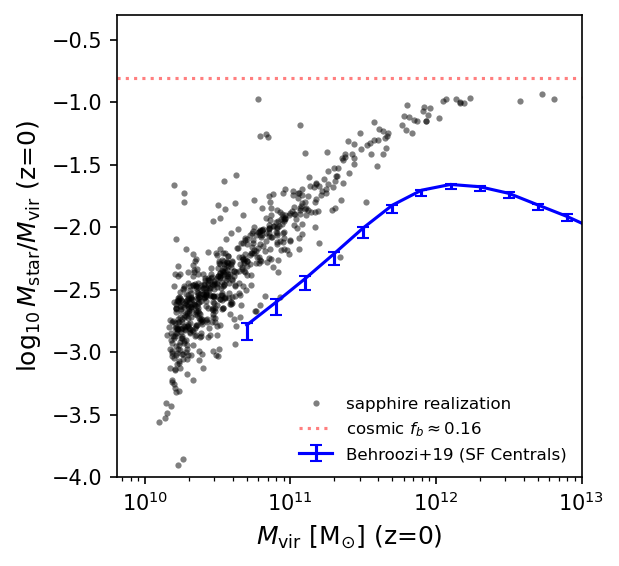

In [36]:
# compare SMHM relation from Behroozi vs this realization of our model

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

# plot Behroozi+19 relation including only central SF galaxies/halos
ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire realization')

ax.set_xscale('log')
ax.set_xlim(None,1e13)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)


In [37]:
### now what if we wanted to do another realization with updated parameters?
### in that case, we just update the parameters dictionary and re-call sapphire.run 

# for example here we increase feedback via increasing specific energy of galactic winds
# i.e., we decrease the mass loading factor normalization and increase the energy loading factor normalization, with all else fixed
parameters.update({'etaM_A':0.1, 'etaE_A':1.0}) # before these were 1.0 and 0.1 respectively 

In [38]:
tstart = timer()
df_results2 = sapphire.run(parameters) # assign to a new dataframe variable name 
print('Finished in %s sec'%(timer()-tstart))


Parsing input parameters...
Reading trees...
Interpolating trees...
Evolving model halos...
We will process 10 trees in parallel...
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124282747
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124282875
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124284376
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124052772
<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=1124283830
Returning dictionary of results directly instead of writing output files
Finished in 213.2081458339817 sec


In [49]:
# re-pull the new z=0 Mvir and Mstar values
z0_Mvir2 = np.array([df_results2.iloc[irow]['Mvir'][-1] for irow in range(len(df_results2))])
z0_Mstar2 = np.array([df_results2.iloc[irow]['M_star'][-1] for irow in range(len(df_results2))])

Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

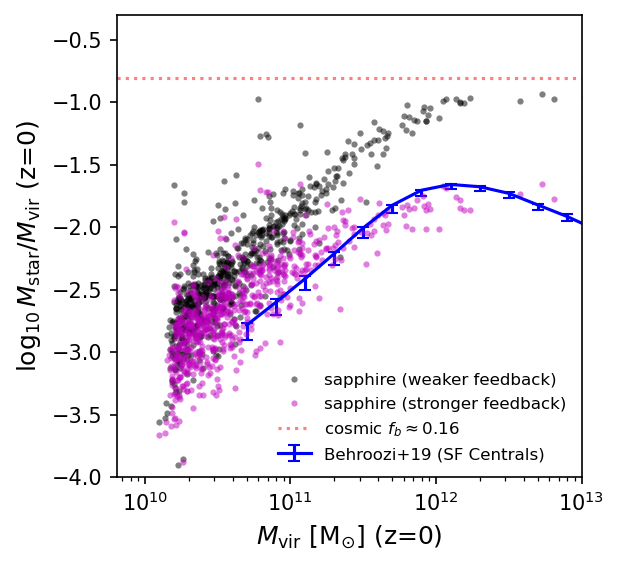

In [50]:
# remake the previous plot with both model predictions now
# the new realization's SMHM points should be lower due to stronger feedback reducing z=0 Mstar 

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

# plot Behroozi+19 relation including only central SF galaxies/halos
ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire (weaker feedback)')
ax.plot(z0_Mvir2,np.log10(z0_Mstar2/z0_Mvir2),'m.',alpha=0.5,mec='none',label='sapphire (stronger feedback)')

ax.set_xscale('log')
ax.set_xlim(None,1e13)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)
